In [1]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/Bank Customer Churn Prediction.csv")

# Display first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Bank Customer Churn Prediction.csv'

In [3]:
import os

print("Files in /content:")
for file in os.listdir("/content"):
    print(file)

Files in /content:
.config
archive (1).zip
sample_data


In [2]:
import os

print("Files in /content:")
for file in os.listdir("/content"):
    print(file)

Files in /content:
.config
sample_data


In [4]:
import zipfile
import os

zip_path = "/content/archive (1).zip"
extract_path = "/content/bank_churn_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [5]:
import os

for root, dirs, files in os.walk("/content/bank_churn_dataset"):
    for file in files:
        print(os.path.join(root, file))


/content/bank_churn_dataset/Bank Customer Churn Prediction.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Bank Customer Churn dataset
file_path = "/content/bank_churn_dataset/Bank Customer Churn Prediction.csv"

df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# Check dataset dimensions
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (10000, 12)

Column Names:
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: f

In [8]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nNumber of Duplicate Rows:", df.duplicated().sum())

Missing Values:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Number of Duplicate Rows: 0


In [9]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nNumber of Duplicate Rows:", df.duplicated().sum())

Missing Values:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Number of Duplicate Rows: 0


In [10]:
# Check target variable distribution

print("Churn Value Counts:")
print(df["churn"].value_counts())

print("\nChurn Percentage:")
print(df["churn"].value_counts(normalize=True) * 100)

Churn Value Counts:
churn
0    7963
1    2037
Name: count, dtype: int64

Churn Percentage:
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


In [11]:
# Display unique values in categorical columns

print("Gender:", df["gender"].unique())
print("Country:", df["country"].unique())
print("Credit Card:", df["credit_card"].unique())
print("Active Member:", df["active_member"].unique())
print("Churn:", df["churn"].unique())

Gender: ['Female' 'Male']
Country: ['France' 'Spain' 'Germany']
Credit Card: [1 0]
Active Member: [1 0]
Churn: [1 0]


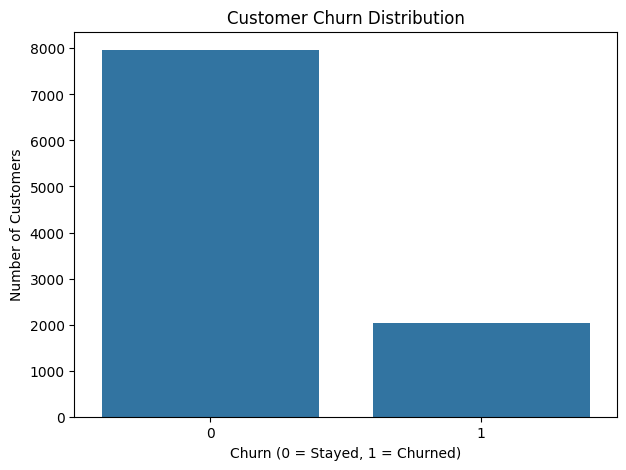

In [12]:
# EDA Plot 1: Customer Churn Distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.show()

In [13]:
# Display exact churn counts

churn_counts = df["churn"].value_counts().sort_index()

print("Customers Stayed (0):", churn_counts[0])
print("Customers Churned (1):", churn_counts[1])

Customers Stayed (0): 7963
Customers Churned (1): 2037


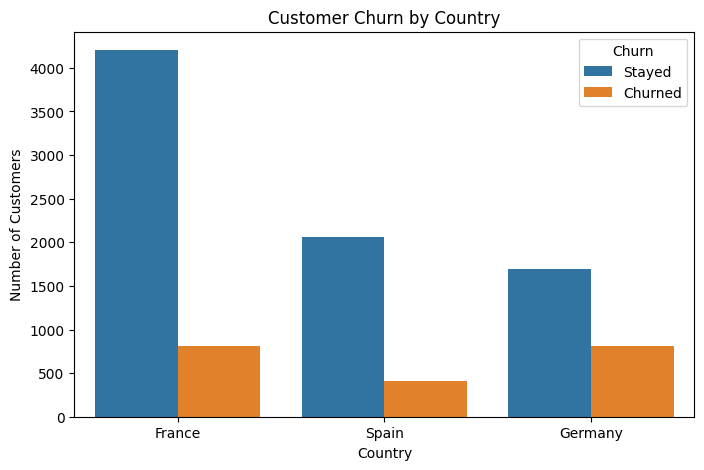

In [14]:
# EDA Plot 2: Churn by Country

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="country", hue="churn")

plt.title("Customer Churn by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["Stayed", "Churned"])

plt.show()

In [15]:
# Calculate churn rate by country

country_churn_rate = df.groupby("country")["churn"].mean() * 100

print("Churn Rate by Country:")
print(country_churn_rate.round(2))

Churn Rate by Country:
country
France     16.15
Germany    32.44
Spain      16.67
Name: churn, dtype: float64


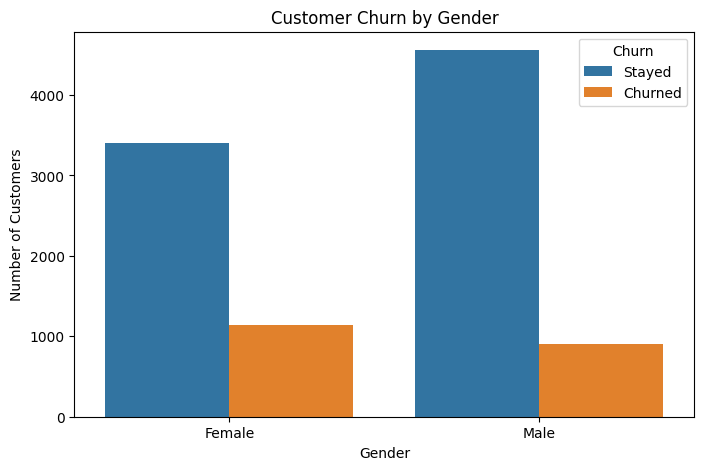

In [16]:
# EDA Plot 3: Customer Churn by Gender

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="gender", hue="churn")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["Stayed", "Churned"])

plt.show()

In [17]:
# Calculate churn rate by gender

gender_churn_rate = df.groupby("gender")["churn"].mean() * 100

print("Churn Rate by Gender:")
print(gender_churn_rate.round(2))

Churn Rate by Gender:
gender
Female    25.07
Male      16.46
Name: churn, dtype: float64


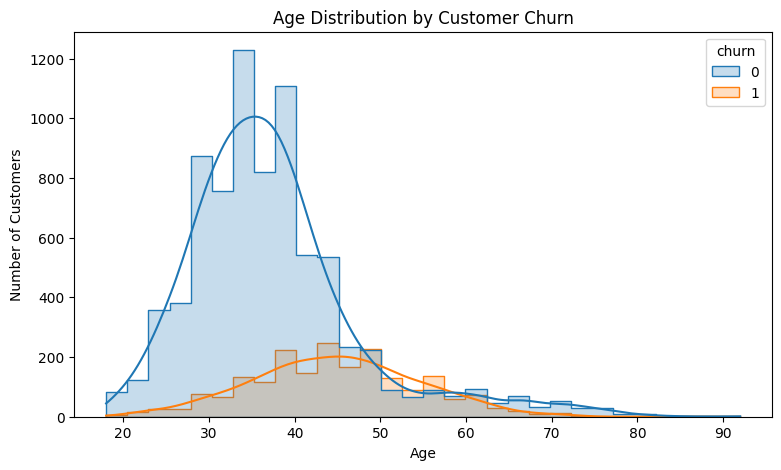

In [18]:
# EDA Plot 4: Age Distribution by Churn

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="age",
    hue="churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Age Distribution by Customer Churn")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
# Average age by churn status

print("Average Age by Churn Status:")
print(df.groupby("churn")["age"].mean().round(2))

Average Age by Churn Status:
churn
0    37.41
1    44.84
Name: age, dtype: float64


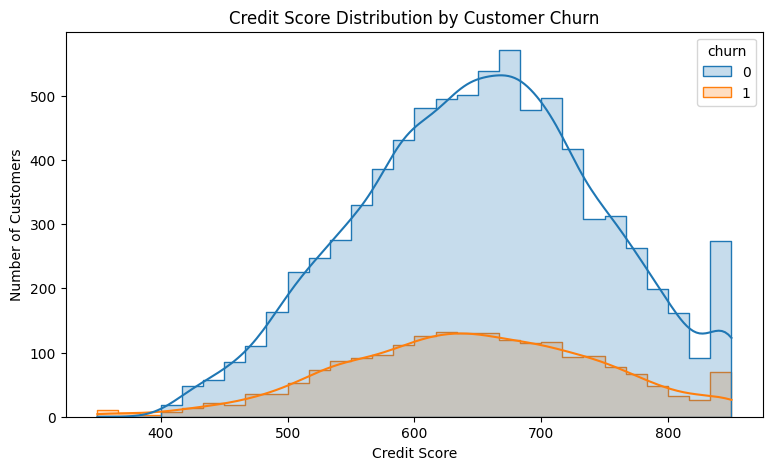

In [20]:
# EDA Plot 5: Credit Score Distribution by Churn

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="credit_score",
    hue="churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Credit Score Distribution by Customer Churn")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")

plt.show()

In [21]:
# Average credit score by churn status

print("Average Credit Score by Churn Status:")
print(df.groupby("churn")["credit_score"].mean().round(2))

Average Credit Score by Churn Status:
churn
0    651.85
1    645.35
Name: credit_score, dtype: float64


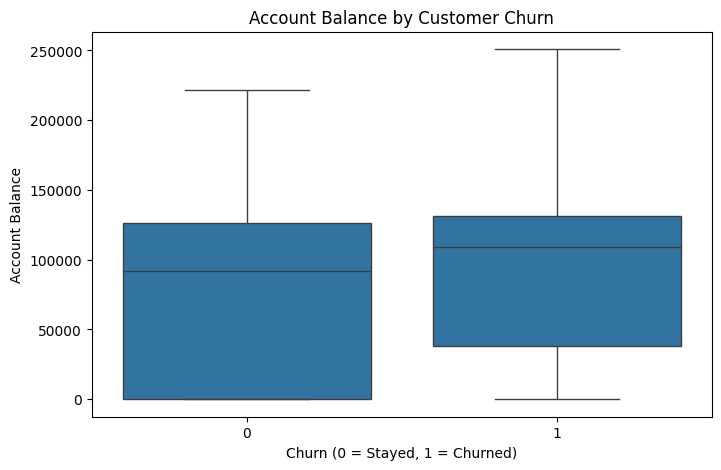

In [22]:
# EDA Plot 6: Account Balance by Churn

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="churn",
    y="balance"
)

plt.title("Account Balance by Customer Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Account Balance")

plt.show()

In [23]:
# Average balance by churn status

print("Average Account Balance by Churn Status:")
print(df.groupby("churn")["balance"].mean().round(2))

Average Account Balance by Churn Status:
churn
0    72745.30
1    91108.54
Name: balance, dtype: float64


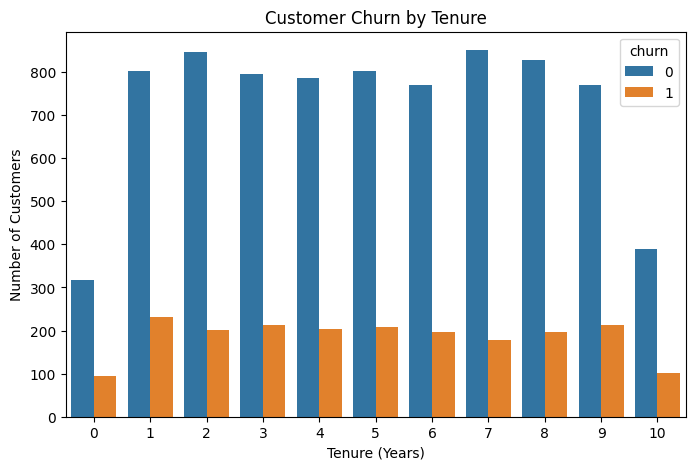

In [24]:
## EDA Plot 7: Tenure by Churn

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="tenure",
    hue="churn"
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Number of Customers")

plt.show()

In [25]:
print("Average Tenure by Churn Status:")
print(df.groupby("churn")["tenure"].mean().round(2))

Average Tenure by Churn Status:
churn
0    5.03
1    4.93
Name: tenure, dtype: float64


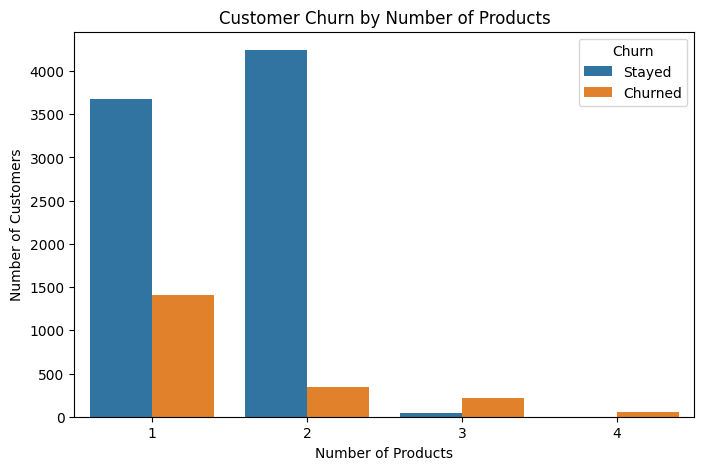

In [26]:
# EDA Plot 8: Number of Products vs Churn

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="products_number",
    hue="churn"
)

plt.title("Customer Churn by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["Stayed", "Churned"])

plt.show()

In [27]:
# Churn rate by number of products

product_churn_rate = df.groupby("products_number")["churn"].mean() * 100

print("Churn Rate by Number of Products:")
print(product_churn_rate.round(2))

Churn Rate by Number of Products:
products_number
1     27.71
2      7.58
3     82.71
4    100.00
Name: churn, dtype: float64


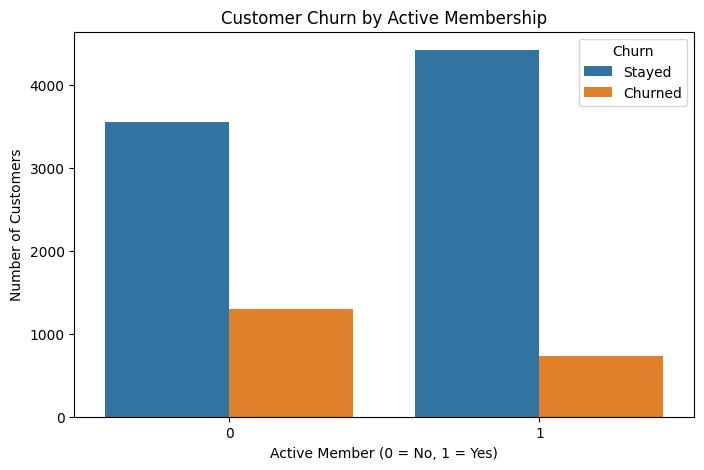

In [28]:
# EDA Plot 9: Active Membership vs Churn

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="active_member",
    hue="churn"
)

plt.title("Customer Churn by Active Membership")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["Stayed", "Churned"])

plt.show()

In [ ]:
# Churn rate by active membership

active_churn_rate = df.groupby("active_member")["churn"].mean() * 100

print("Churn Rate by Active Membership:")
print(active_churn_rate.round(2))

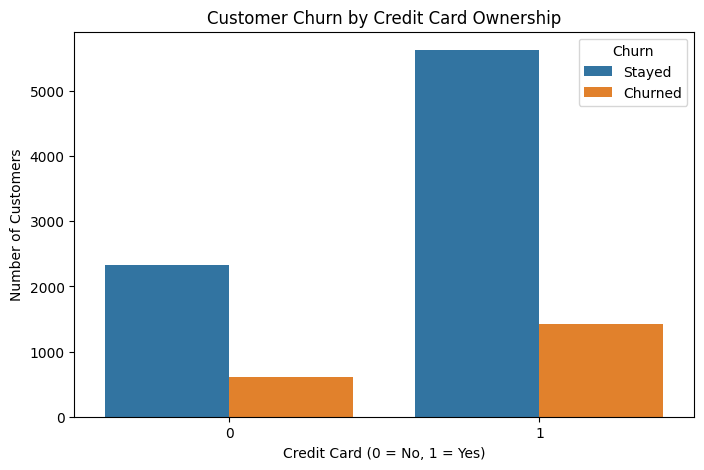

In [29]:
# EDA: Credit Card Ownership vs Churn

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="credit_card",
    hue="churn"
)

plt.title("Customer Churn by Credit Card Ownership")
plt.xlabel("Credit Card (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["Stayed", "Churned"])

plt.show()

In [30]:
# Churn rate by credit card ownership

credit_card_churn_rate = df.groupby("credit_card")["churn"].mean() * 100

print("Churn Rate by Credit Card Ownership:")
print(credit_card_churn_rate.round(2))

Churn Rate by Credit Card Ownership:
credit_card
0    20.81
1    20.18
Name: churn, dtype: float64


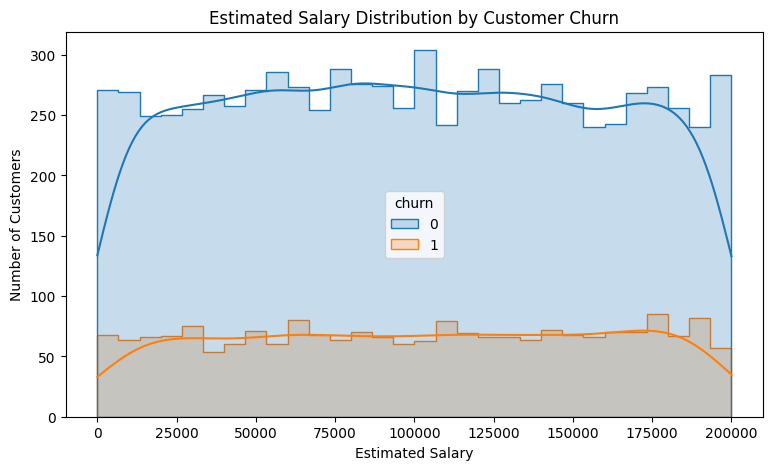

In [31]:
# EDA Plot: Estimated Salary Distribution by Churn

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="estimated_salary",
    hue="churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Estimated Salary Distribution by Customer Churn")
plt.xlabel("Estimated Salary")
plt.ylabel("Number of Customers")

plt.show()

In [32]:
# Average estimated salary by churn status

print("Average Estimated Salary by Churn Status:")
print(df.groupby("churn")["estimated_salary"].mean().round(2))

Average Estimated Salary by Churn Status:
churn
0     99738.39
1    101465.68
Name: estimated_salary, dtype: float64


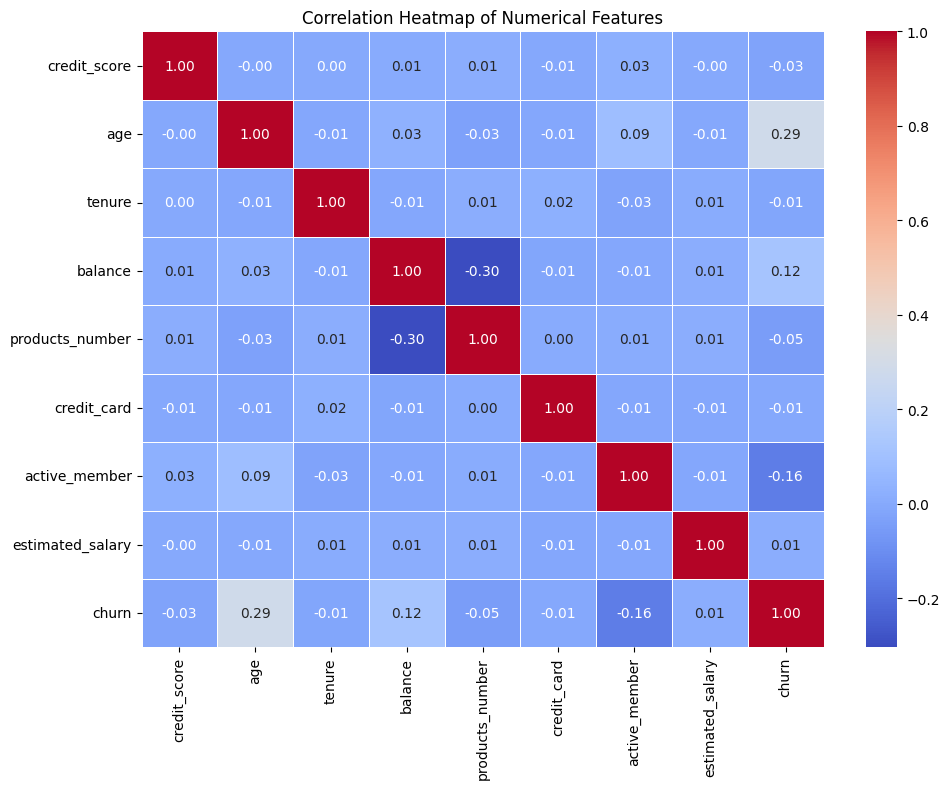

In [33]:
# EDA Plot: Correlation Heatmap

numerical_columns = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "credit_card",
    "active_member",
    "estimated_salary",
    "churn"
]

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [34]:
# Remove customer_id because it is only an identifier

df_model = df.drop("customer_id", axis=1)

print("Columns after removing customer_id:")
print(df_model.columns.tolist())

Columns after removing customer_id:
['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


In [35]:
# Convert categorical variables into numerical variables

df_model = pd.get_dummies(
    df_model,
    columns=["country", "gender"],
    drop_first=True,
    dtype=int
)

print("Dataset after encoding:")
print(df_model.head())

print("\nColumns:")
print(df_model.columns.tolist())

Dataset after encoding:
   credit_score  age  tenure    balance  products_number  credit_card  \
0           619   42       2       0.00                1            1   
1           608   41       1   83807.86                1            0   
2           502   42       8  159660.80                3            1   
3           699   39       1       0.00                2            0   
4           850   43       2  125510.82                1            1   

   active_member  estimated_salary  churn  country_Germany  country_Spain  \
0              1         101348.88      1                0              0   
1              1         112542.58      0                0              1   
2              0         113931.57      1                0              0   
3              0          93826.63      0                0              0   
4              1          79084.10      0                0              1   

   gender_Male  
0            0  
1            0  
2            0  
3     

In [36]:
# Separate independent variables (X) and dependent variable (y)

X = df_model.drop("churn", axis=1)
y = df_model["churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (10000, 11)
y shape: (10000,)

Features:
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_Germany', 'country_Spain', 'gender_Male']


In [37]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (8000, 11)
Testing data shape: (2000, 11)
Training target shape: (8000,)
Testing target shape: (2000,)


In [38]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model

model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
# Predict churn for the test dataset

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]


In [40]:
# Predict probability of customer churn

y_prob = model.predict_proba(X_test)[:, 1]

print("Churn probabilities:")
print(y_prob[:20])

Churn probabilities:
[0.11587372 0.31090482 0.15358613 0.16311032 0.13403432 0.18494409
 0.10083553 0.37433415 0.33832774 0.20694383 0.46893208 0.23939076
 0.08413531 0.17792237 0.16906408 0.04173683 0.24674375 0.3781973
 0.70485845 0.51489864]


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy  : 0.8070
Precision : 0.6000
Recall    : 0.1548
F1-Score  : 0.2461
ROC-AUC   : 0.7621


Confusion Matrix:
[[1551   42]
 [ 344   63]]


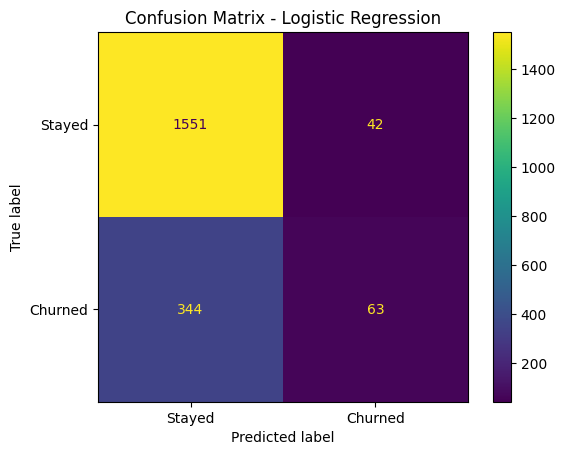

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

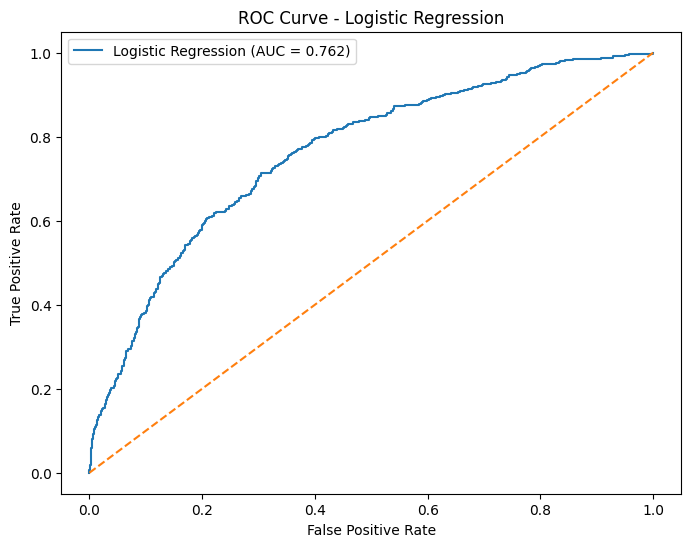

ROC-AUC Score: 0.7621


In [43]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

print("ROC-AUC Score:", round(auc_score, 4))

In [44]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Churned"]
))

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
     Churned       0.60      0.15      0.25       407

    accuracy                           0.81      2000
   macro avg       0.71      0.56      0.57      2000
weighted avg       0.77      0.81      0.76      2000



In [45]:
# Get model coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Calculate absolute coefficient
coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

# Sort by importance
coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("Feature Importance based on Logistic Regression Coefficients:")
print(coefficients.to_string(index=False))

Feature Importance based on Logistic Regression Coefficients:
         Feature   Coefficient  Absolute_Coefficient
   active_member -9.035831e-01          9.035831e-01
 country_Germany  9.001838e-01          9.001838e-01
     gender_Male -5.744831e-01          5.744831e-01
 products_number -2.262428e-01          2.262428e-01
   country_Spain  2.143468e-01          2.143468e-01
     credit_card -1.107182e-01          1.107182e-01
             age  5.497331e-02          5.497331e-02
          tenure -1.868981e-02          1.868981e-02
    credit_score -1.715810e-03          1.715810e-03
         balance  1.909048e-06          1.909048e-06
estimated_salary  4.826406e-07          4.826406e-07


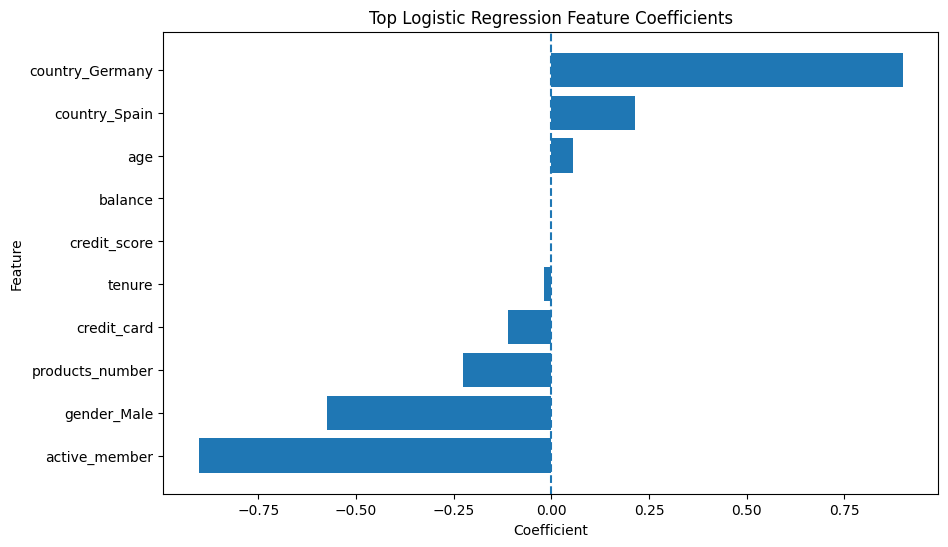

In [46]:
# Select top features

top_features = coefficients.head(10).sort_values("Coefficient")

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.title("Top Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print("Variance Inflation Factor (VIF):")
print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))

Variance Inflation Factor (VIF):
         Feature       VIF
    credit_score 21.236445
             age 12.334128
 products_number  7.826417
estimated_salary  3.887186
          tenure  3.872755
     credit_card  3.289605
         balance  3.182267
     gender_Male  2.168988
   active_member  2.075966
 country_Germany  1.787170
   country_Spain  1.486247


In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create standardized Logistic Regression model

scaled_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

# Train standardized model
scaled_model.fit(X_train, y_train)

# Predictions
y_pred_scaled = scaled_model.predict(X_test)
y_prob_scaled = scaled_model.predict_proba(X_test)[:, 1]

print("Standardized Logistic Regression model trained successfully.")

Standardized Logistic Regression model trained successfully.


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

scaled_accuracy = accuracy_score(y_test, y_pred_scaled)
scaled_precision = precision_score(y_test, y_pred_scaled)
scaled_recall = recall_score(y_test, y_pred_scaled)
scaled_f1 = f1_score(y_test, y_pred_scaled)
scaled_auc = roc_auc_score(y_test, y_prob_scaled)

print("Standardized Logistic Regression Performance")
print("---------------------------------------------")
print(f"Accuracy  : {scaled_accuracy:.4f}")
print(f"Precision : {scaled_precision:.4f}")
print(f"Recall    : {scaled_recall:.4f}")
print(f"F1-Score  : {scaled_f1:.4f}")
print(f"ROC-AUC   : {scaled_auc:.4f}")

Standardized Logistic Regression Performance
---------------------------------------------
Accuracy  : 0.8080
Precision : 0.5891
Recall    : 0.1867
F1-Score  : 0.2836
ROC-AUC   : 0.7748


In [50]:
model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Original Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Standardized Logistic Regression": [
        scaled_accuracy,
        scaled_precision,
        scaled_recall,
        scaled_f1,
        scaled_auc
    ]
})

model_comparison

,Metric,Original Logistic Regression,Standardized Logistic Regression
0,Accuracy,0.807000,0.808000
1,Precision,0.600000,0.589147
2,Recall,0.154791,0.186732
3,F1-Score,0.246094,0.283582
4,ROC-AUC,0.762137,0.774778


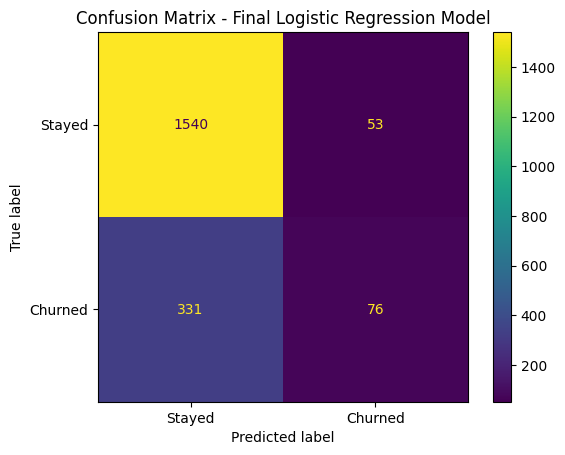

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_scaled = confusion_matrix(y_test, y_pred_scaled)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_scaled,
    display_labels=["Stayed", "Churned"]
)

disp.plot()

plt.title("Confusion Matrix - Final Logistic Regression Model")
plt.show()

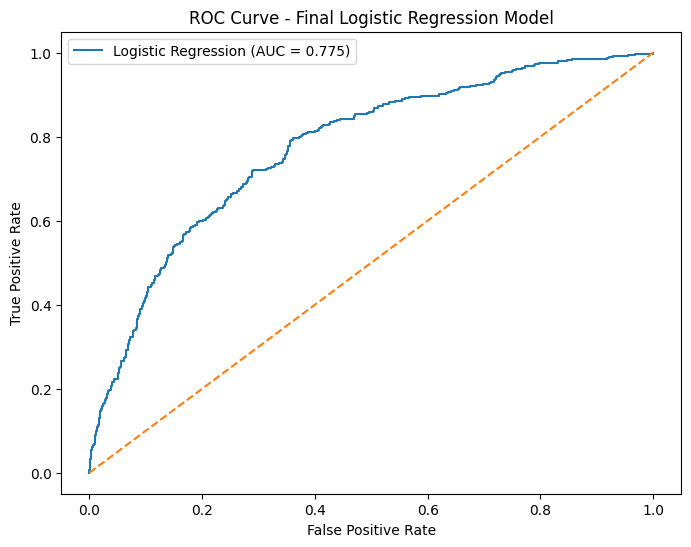

In [52]:
fpr_scaled, tpr_scaled, thresholds_scaled = roc_curve(
    y_test,
    y_prob_scaled
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_scaled,
    tpr_scaled,
    label=f"Logistic Regression (AUC = {scaled_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Final Logistic Regression Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [53]:
# Extract coefficients from standardized Logistic Regression

scaled_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": scaled_model.named_steps["logistic"].coef_[0]
})

scaled_coefficients["Absolute_Coefficient"] = (
    scaled_coefficients["Coefficient"].abs()
)

scaled_coefficients = scaled_coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("Final Feature Importance:")
print(scaled_coefficients.to_string(index=False))

Final Feature Importance:
         Feature  Coefficient  Absolute_Coefficient
             age     0.738847              0.738847
   active_member    -0.515485              0.515485
 country_Germany     0.356679              0.356679
     gender_Male    -0.260851              0.260851
         balance     0.160622              0.160622
    credit_score    -0.085986              0.085986
 products_number    -0.070292              0.070292
estimated_salary     0.047725              0.047725
     credit_card    -0.032208              0.032208
          tenure    -0.020071              0.020071
   country_Spain     0.018907              0.018907


In [54]:
# Calculate odds ratios

scaled_coefficients["Odds_Ratio"] = np.exp(
    scaled_coefficients["Coefficient"]
)

print("Feature Coefficients and Odds Ratios:")
print(
    scaled_coefficients[
        ["Feature", "Coefficient", "Odds_Ratio"]
    ].to_string(index=False)
)

Feature Coefficients and Odds Ratios:
         Feature  Coefficient  Odds_Ratio
             age     0.738847    2.093520
   active_member    -0.515485    0.597211
 country_Germany     0.356679    1.428578
     gender_Male    -0.260851    0.770396
         balance     0.160622    1.174241
    credit_score    -0.085986    0.917607
 products_number    -0.070292    0.932122
estimated_salary     0.047725    1.048882
     credit_card    -0.032208    0.968306
          tenure    -0.020071    0.980129
   country_Spain     0.018907    1.019087


In [55]:
print("=" * 50)
print("FINAL LOGISTIC REGRESSION MODEL")
print("=" * 50)

print(f"Accuracy  : {scaled_accuracy:.4f}")
print(f"Precision : {scaled_precision:.4f}")
print(f"Recall    : {scaled_recall:.4f}")
print(f"F1-Score  : {scaled_f1:.4f}")
print(f"ROC-AUC   : {scaled_auc:.4f}")

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))
print("Number of Features:", X.shape[1])

FINAL LOGISTIC REGRESSION MODEL
Accuracy  : 0.8080
Precision : 0.5891
Recall    : 0.1867
F1-Score  : 0.2836
ROC-AUC   : 0.7748

Training Samples: 8000
Testing Samples : 2000
Number of Features: 11


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)

print(f"Accuracy  : {accuracy_score(y_test, y_pred_scaled):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_scaled):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_scaled):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_scaled):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_scaled):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaled))

print("\nFeature Coefficients and Odds Ratios:")
print(scaled_coefficients[["Feature", "Coefficient", "Odds_Ratio"]].to_string(index=False))

print("\nVIF:")
print(vif_data.sort_values("VIF", ascending=False).to_string(index=False))

FINAL MODEL RESULTS
Accuracy  : 0.8080
Precision : 0.5891
Recall    : 0.1867
F1-Score  : 0.2836
ROC-AUC   : 0.7748

Confusion Matrix:
[[1540   53]
 [ 331   76]]

Feature Coefficients and Odds Ratios:
         Feature  Coefficient  Odds_Ratio
             age     0.738847    2.093520
   active_member    -0.515485    0.597211
 country_Germany     0.356679    1.428578
     gender_Male    -0.260851    0.770396
         balance     0.160622    1.174241
    credit_score    -0.085986    0.917607
 products_number    -0.070292    0.932122
estimated_salary     0.047725    1.048882
     credit_card    -0.032208    0.968306
          tenure    -0.020071    0.980129
   country_Spain     0.018907    1.019087

VIF:
         Feature       VIF
    credit_score 21.236445
             age 12.334128
 products_number  7.826417
estimated_salary  3.887186
          tenure  3.872755
     credit_card  3.289605
         balance  3.182267
     gender_Male  2.168988
   active_member  2.075966
 country_Germany  1.

In [57]:
vif_data = vif_data.sort_values("VIF", ascending=False)

vif_data

,Feature,VIF
0,credit_score,21.236445
1,age,12.334128
4,products_number,7.826417
7,estimated_salary,3.887186
2,tenure,3.872755
5,credit_card,3.289605
3,balance,3.182267
10,gender_Male,2.168988
6,active_member,2.075966
8,country_Germany,1.787170
